# Semana 3: Desarrollo de modelos

https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import warnings
warnings.filterwarnings("ignore")

### Pregunta 1

In [2]:
file_path = "Steel_industry_data.csv"
df = pd.read_csv(file_path)
df

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


In [3]:
df.dtypes

date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

In [4]:
df.isnull().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

In [5]:
df.rename(columns={'Usage_kWh':'Usage','Lagging_Current_Reactive.Power_kVarh':'Lagging_CRP',
                   'Leading_Current_Reactive_Power_kVarh':'Leading_CRP','CO2(tCO2)':'CO2',
                   'Lagging_Current_Power_Factor':'Lagging_CPF','Leading_Current_Power_Factor':'Leading_CPF'},
                   inplace=True)
df

,date,Usage,Lagging_CRP,Leading_CRP,CO2,Lagging_CPF,Leading_CPF,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


In [6]:
df.columns

Index(['date', 'Usage', 'Lagging_CRP', 'Leading_CRP', 'CO2', 'Lagging_CPF',
       'Leading_CPF', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

In [7]:
v_numericas = df.select_dtypes(["float64","int64"])
v_numericas = list(v_numericas.columns)
v_numericas

['Usage',
 'Lagging_CRP',
 'Leading_CRP',
 'CO2',
 'Lagging_CPF',
 'Leading_CPF',
 'NSM']

In [8]:
df[v_numericas].corr()

,Usage,Lagging_CRP,Leading_CRP,CO2,Lagging_CPF,Leading_CPF,NSM
Usage,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,0.234610
Lagging_CRP,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,0.082662
Leading_CRP,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,0.371605
CO2,0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,0.231726
Lagging_CPF,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,0.565270
Leading_CPF,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-0.360563
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000


### Pregunta 2

In [9]:
cdf = df[['Lagging_CRP','Leading_CRP','NSM','Usage']]
cdf.head()

,Lagging_CRP,Leading_CRP,NSM,Usage
0,2.95,0.0,900,3.17
1,4.46,0.0,1800,4.00
2,3.28,0.0,2700,3.24
3,3.56,0.0,3600,3.31
4,4.50,0.0,4500,3.82


In [10]:
# Regresión simple usando la librería sklearn
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
x = df[['Lagging_CRP']]
y = df['Usage']

In [11]:
lm.fit(x, y)
b0 = lm.intercept_
b1 = lm.coef_
print('Intercepto =', b0)
print('Coeficiente =', b1)

Intercepto = 3.427258164201085
Coeficiente = [1.83804597]


$$ \hat{y} =  3.427 + 1.838x $$

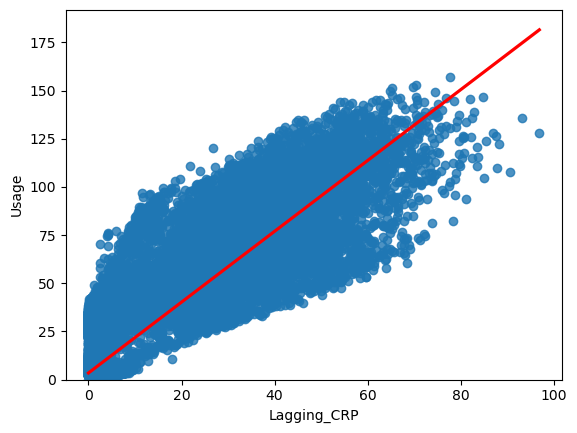

In [12]:
sns.regplot(x="Lagging_CRP", y="Usage", data=df, fit_reg=True, line_kws={"color": "red"})
plt.ylim(0,)
plt.show()

In [13]:
# Regresión simple usando la librería sklearn
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
x = df[['Leading_CRP']]
y = df['Usage']

In [14]:
lm.fit(x, y)
b0 = lm.intercept_
b1 = lm.coef_
print('Intercepto =', b0)
print('Coeficiente =', b1)

Intercepto = 33.05260251772451
Coeficiente = [-1.463649]


$$ \hat{y} =  33.053 - 1.464x $$

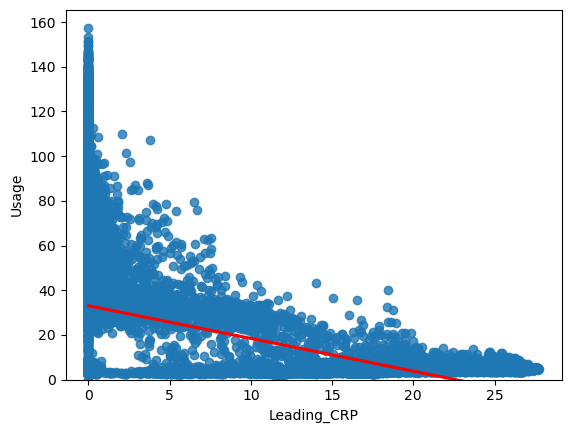

In [15]:
sns.regplot(x="Leading_CRP", y="Usage", data=df, fit_reg=True, line_kws={"color": "red"})
plt.ylim(0,)
plt.show()

In [16]:
# Regresión simple usando la librería sklearn
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
x = df[['NSM']]
y = df['Usage']

In [17]:
lm.fit(x, y)
b0 = lm.intercept_
b1 = lm.coef_
print('Intercepto =', b0)
print('Coeficiente =', b1)

Intercepto = 13.937562820693893
Coeficiente = [0.0003146]


$$ \hat{y} =  13.938 + 0.0003x $$

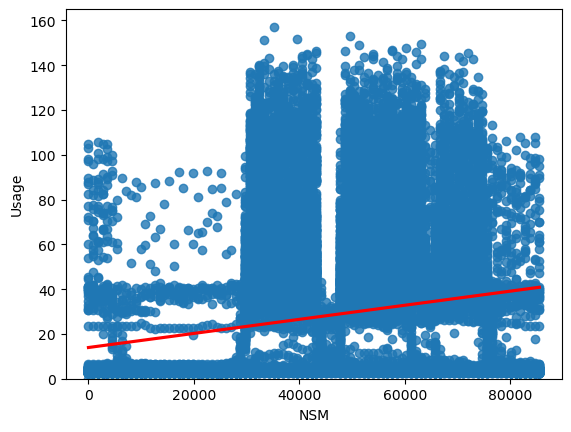

In [18]:
sns.regplot(x="NSM", y="Usage", data=df, fit_reg=True, line_kws={"color": "red"})
plt.ylim(0,)
plt.show()

### Pregunta 3

In [19]:
# Regresión usando la librería sklearn
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
x = cdf[['Lagging_CRP','Leading_CRP','NSM']]
y = cdf[['Usage']]

In [20]:
lm.fit(x, y)
b0 = lm.intercept_
b = lm.coef_
print('Intercepto =', b0)
print('Coeficientes =', b)

Intercepto = [-5.245644]
Coeficientes = [[ 1.77395586e+00 -1.83591388e-01  2.39041267e-04]]


$$ \hat{y} =  -5.246 + 1.774x1 - 0.184x2 + 0.0002x3 $$

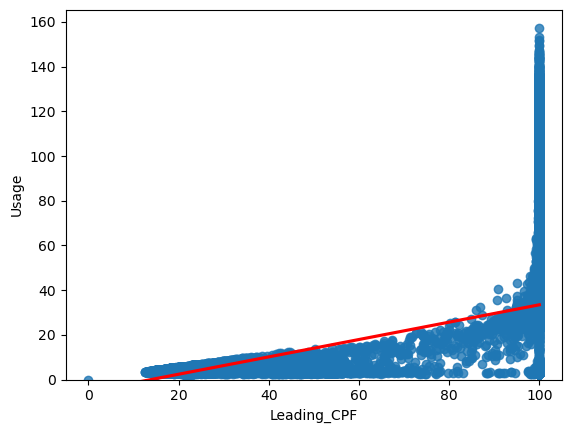

In [21]:
sns.regplot(x="Leading_CPF", y="Usage", data=df, fit_reg=True, line_kws={"color": "red"})
plt.ylim(0,)
plt.show()

In [22]:
# Regresión polinómica de grado 3
x = df['Leading_CPF']
y = df['Usage']
grado = 3
f = np.polyfit(x, y, grado)
print("Coeficientes =" ,f)

Coeficientes = [ 1.39266149e-04 -1.69819434e-02  6.83959776e-01 -4.06923215e+00]


In [23]:
p = np.poly1d(f)
print(p)

           3           2
0.0001393 x - 0.01698 x + 0.684 x - 4.069


$$ \hat{y} =  -4.069 + 0.684x - 0.017x^2 + 0.0001x^3 $$

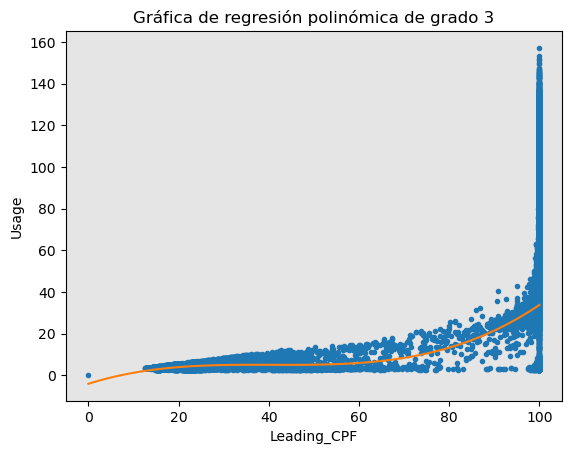

In [24]:
def plot_poly(model, independent_variable, dependent_variable, name):
    x_new = np.linspace(0, 100, 100)
    y_new = model(x_new)
    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title('Gráfica de regresión polinómica de grado 3')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(name)
    plt.ylabel('Usage')
    plt.show()

plot_poly(p, x, y, 'Leading_CPF')

### Pregunta 4

In [25]:
lm = LinearRegression()
x = cdf[['Lagging_CRP']]
y = cdf['Usage']
lm.fit(x, y)

LinearRegression()

In [26]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_hat = lm.predict(x)
print("MSE = %.2f" % mean_squared_error(y, y_hat))
print("R2 = %.3f" % r2_score(y, y_hat))

MSE = 220.25
R2 = 0.803


In [27]:
lm = LinearRegression()
x = cdf[['Leading_CRP']]
y = cdf['Usage']
lm.fit(x, y)

LinearRegression()

In [28]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_hat = lm.predict(x)
print("MSE = %.2f" % mean_squared_error(y, y_hat))
print("R2 = %.3f" % r2_score(y, y_hat))

MSE = 1000.41
R2 = 0.106


In [29]:
lm = LinearRegression()
x = cdf[['NSM']]
y = cdf['Usage']
lm.fit(x, y)

LinearRegression()

In [30]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_hat = lm.predict(x)
print("MSE = %.2f" % mean_squared_error(y, y_hat))
print("R2 = %.3f" % r2_score(y, y_hat))

MSE = 1056.93
R2 = 0.055


In [31]:
lm = LinearRegression()
x = cdf[['Lagging_CRP','Leading_CRP','NSM']]
y = cdf['Usage']
lm.fit(x, y)

LinearRegression()

In [32]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_hat = lm.predict(x)
print("MSE = %.2f" % mean_squared_error(y, y_hat))
print("R2 = %.3f" % r2_score(y, y_hat))

MSE = 189.98
R2 = 0.830


In [33]:
df1 = cdf[['Lagging_CRP','Usage']]
df1

,Lagging_CRP,Usage
0,2.95,3.17
1,4.46,4.00
2,3.28,3.24
3,3.56,3.31
4,4.50,3.82
...,...,...
35035,4.86,3.85
35036,3.74,3.74
35037,3.17,3.78
35038,3.06,3.78


In [34]:
# Regresión usando la librería statsmodels
import statsmodels.formula.api as smf
results = smf.ols('Usage ~  Lagging_CRP', data=df1).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Usage   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                 1.429e+05
Date:                Sun, 04 Aug 2024   Prob (F-statistic):               0.00
Time:                        19:47:22   Log-Likelihood:            -1.4424e+05
No. Observations:               35040   AIC:                         2.885e+05
Df Residuals:                   35038   BIC:                         2.885e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.4273      0.102     33.764      

In [35]:
y_pred = results.predict(df1['Lagging_CRP'])
df1["Usage_hat"] = y_pred
df1["Error"] = df1["Usage"] - df1["Usage_hat"] 
df1

,Lagging_CRP,Usage,Usage_hat,Error
0,2.95,3.17,8.849494,-5.679494
1,4.46,4.00,11.624943,-7.624943
2,3.28,3.24,9.456049,-6.216049
3,3.56,3.31,9.970702,-6.660702
4,4.50,3.82,11.698465,-7.878465
...,...,...,...,...
35035,4.86,3.85,12.360162,-8.510162
35036,3.74,3.74,10.301550,-6.561550
35037,3.17,3.78,9.253864,-5.473864
35038,3.06,3.78,9.051679,-5.271679


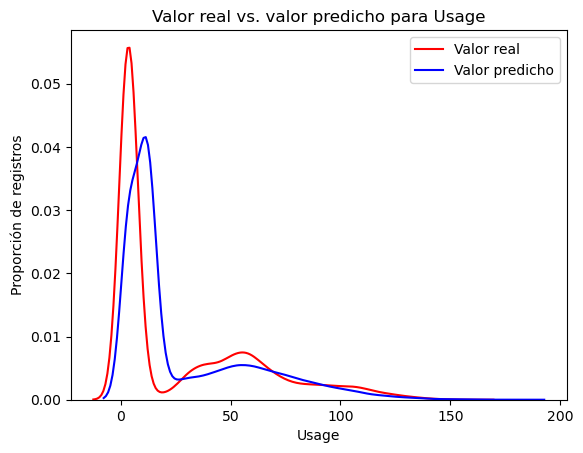

In [36]:
ax = sns.distplot(df1['Usage'], hist=False, color="r", label="Valor real")
sns.distplot(y_pred, hist=False, color="b", label="Valor predicho", ax=ax)
plt.title('Valor real vs. valor predicho para Usage')
plt.xlabel('Usage')
plt.ylabel('Proporción de registros')
plt.legend()
plt.show()

In [37]:
df2 = cdf[['Leading_CRP','Usage']]
df2

,Leading_CRP,Usage
0,0.00,3.17
1,0.00,4.00
2,0.00,3.24
3,0.00,3.31
4,0.00,3.82
...,...,...
35035,0.00,3.85
35036,0.00,3.74
35037,0.07,3.78
35038,0.11,3.78


In [38]:
# Regresión usando la librería statsmodels
import statsmodels.formula.api as smf
results = smf.ols('Usage ~  Leading_CRP', data=df2).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Usage   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     4136.
Date:                Sun, 04 Aug 2024   Prob (F-statistic):               0.00
Time:                        19:47:23   Log-Likelihood:            -1.7075e+05
No. Observations:               35040   AIC:                         3.415e+05
Df Residuals:                   35038   BIC:                         3.415e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      33.0526      0.191    173.448      

In [39]:
y_pred = results.predict(df2['Leading_CRP'])
df2["Usage_hat"] = y_pred
df2["Error"] = df2["Usage"] - df2["Usage_hat"] 
df2

,Leading_CRP,Usage,Usage_hat,Error
0,0.00,3.17,33.052603,-29.882603
1,0.00,4.00,33.052603,-29.052603
2,0.00,3.24,33.052603,-29.812603
3,0.00,3.31,33.052603,-29.742603
4,0.00,3.82,33.052603,-29.232603
...,...,...,...,...
35035,0.00,3.85,33.052603,-29.202603
35036,0.00,3.74,33.052603,-29.312603
35037,0.07,3.78,32.950147,-29.170147
35038,0.11,3.78,32.891601,-29.111601


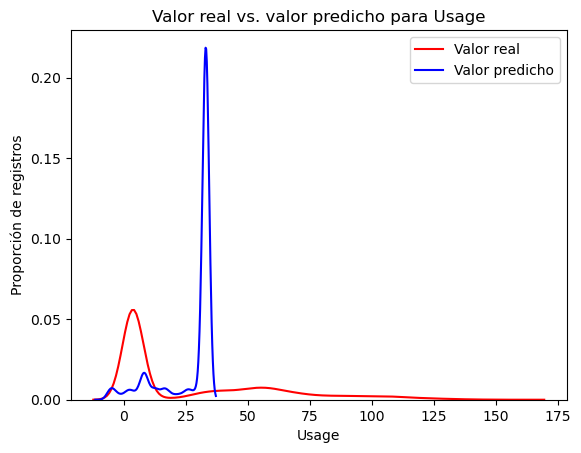

In [40]:
ax = sns.distplot(df2['Usage'], hist=False, color="r", label="Valor real")
sns.distplot(y_pred, hist=False, color="b", label="Valor predicho", ax=ax)
plt.title('Valor real vs. valor predicho para Usage')
plt.xlabel('Usage')
plt.ylabel('Proporción de registros')
plt.legend()
plt.show()

In [41]:
df3 = cdf[['NSM','Usage']]
df3

,NSM,Usage
0,900,3.17
1,1800,4.00
2,2700,3.24
3,3600,3.31
4,4500,3.82
...,...,...
35035,82800,3.85
35036,83700,3.74
35037,84600,3.78
35038,85500,3.78


In [42]:
# Regresión usando la librería statsmodels
import statsmodels.formula.api as smf
results = smf.ols('Usage ~  NSM', data=df3).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Usage   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     2041.
Date:                Sun, 04 Aug 2024   Prob (F-statistic):               0.00
Time:                        19:47:23   Log-Likelihood:            -1.7171e+05
No. Observations:               35040   AIC:                         3.434e+05
Df Residuals:                   35038   BIC:                         3.434e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.9376      0.345     40.438      0.0

In [43]:
y_pred = results.predict(df3['NSM'])
df3["Usage_hat"] = y_pred
df3["Error"] = df3["Usage"] - df3["Usage_hat"] 
df3

,NSM,Usage,Usage_hat,Error
0,900,3.17,14.220707,-11.050707
1,1800,4.00,14.503850,-10.503850
2,2700,3.24,14.786994,-11.546994
3,3600,3.31,15.070138,-11.760138
4,4500,3.82,15.353282,-11.533282
...,...,...,...,...
35035,82800,3.85,39.986791,-36.136791
35036,83700,3.74,40.269934,-36.529934
35037,84600,3.78,40.553078,-36.773078
35038,85500,3.78,40.836222,-37.056222


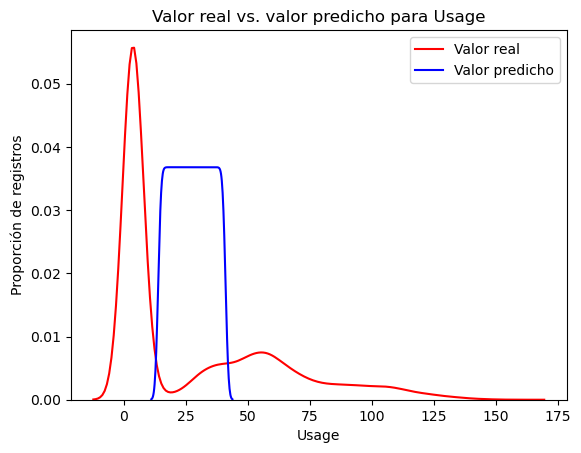

In [44]:
ax = sns.distplot(df3['Usage'], hist=False, color="r", label="Valor real")
sns.distplot(y_pred, hist=False, color="b", label="Valor predicho", ax=ax)
plt.title('Valor real vs. valor predicho para Usage')
plt.xlabel('Usage')
plt.ylabel('Proporción de registros')
plt.legend()
plt.show()

In [45]:
df4 = cdf[['Lagging_CRP','Leading_CRP','NSM','Usage']]
df4

,Lagging_CRP,Leading_CRP,NSM,Usage
0,2.95,0.00,900,3.17
1,4.46,0.00,1800,4.00
2,3.28,0.00,2700,3.24
3,3.56,0.00,3600,3.31
4,4.50,0.00,4500,3.82
...,...,...,...,...
35035,4.86,0.00,82800,3.85
35036,3.74,0.00,83700,3.74
35037,3.17,0.07,84600,3.78
35038,3.06,0.11,85500,3.78


In [46]:
# Regresión usando la librería statsmodels
import statsmodels.formula.api as smf
results = smf.ols('Usage ~  Lagging_CRP + Leading_CRP + NSM', data=df4).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Usage   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                 5.708e+04
Date:                Sun, 04 Aug 2024   Prob (F-statistic):               0.00
Time:                        19:47:24   Log-Likelihood:            -1.4165e+05
No. Observations:               35040   AIC:                         2.833e+05
Df Residuals:                   35036   BIC:                         2.833e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -5.2456      0.155    -33.890      

In [47]:
y_pred = results.predict(df4[['Lagging_CRP','Leading_CRP','NSM','Usage']])
df4["Usage_hat"] = y_pred
df4["Error"] = df4["Usage"] - df4["Usage_hat"] 
df4

,Lagging_CRP,Leading_CRP,NSM,Usage,Usage_hat,Error
0,2.95,0.00,900,3.17,0.202663,2.967337
1,4.46,0.00,1800,4.00,3.096473,0.903527
2,3.28,0.00,2700,3.24,1.218343,2.021657
3,3.56,0.00,3600,3.31,1.930187,1.379813
4,4.50,0.00,4500,3.82,3.812843,0.007157
...,...,...,...,...,...,...
35035,4.86,0.00,82800,3.85,23.168398,-19.318398
35036,3.74,0.00,83700,3.74,21.396705,-17.656705
35037,3.17,0.07,84600,3.78,20.587836,-16.807836
35038,3.06,0.11,85500,3.78,20.600494,-16.820494


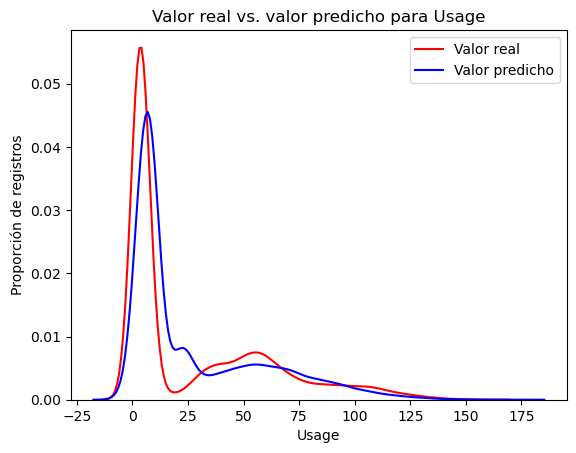

In [48]:
ax = sns.distplot(df4['Usage'], hist=False, color="r", label="Valor real")
sns.distplot(y_pred, hist=False, color="b", label="Valor predicho", ax=ax)
plt.title('Valor real vs. valor predicho para Usage')
plt.xlabel('Usage')
plt.ylabel('Proporción de registros')
plt.legend()
plt.show()